# NFL trajectory research — evidence review

A public, aggregate-only review of controlled feature investigations. Lower coordinate RMSE is better. No private tracking, player identities, model weights, or prediction arrays are used here.

The owner-side publication renderer runs these cells using plain Python and records that execution mechanism. Opening this notebook in Jupyter and running all cells is also supported. No model is trained.


In [1]:
from pathlib import Path
import json
import plotly.graph_objects as go
import plotly.io as pio

if 'PUBLIC_ROOT' not in globals():
    roots = [Path.cwd(), *Path.cwd().parents]
    PUBLIC_ROOT = next(p for p in roots if (p/'research/evidence/studies.json').is_file())
if 'show' not in globals():
    def show(fig):
        fig.show(renderer='plotly_mimetype')
E = json.loads((PUBLIC_ROOT/'research/evidence/studies.json').read_text())
S = E['studies']
print(E['metric'])
print(E['comparison_limit'])
def style(fig, title, x, y):
    fig.update_layout(title=title, xaxis_title=x, yaxis_title=y, height=490,
                      margin=dict(l=85,r=35,t=90,b=100), legend_title_text='Model arm')
    return fig


sqrt(sum(dx^2+dy^2)/(2N)); yards; lower is better
Reused internal game splits. No new Kaggle score or model replay by publication.


## 1. Recent matched studies

Separate arms are shown within each experiment. These are not a trajectory of leaderboard improvements. Models, availability controls, and earlier inspected data can differ across studies.


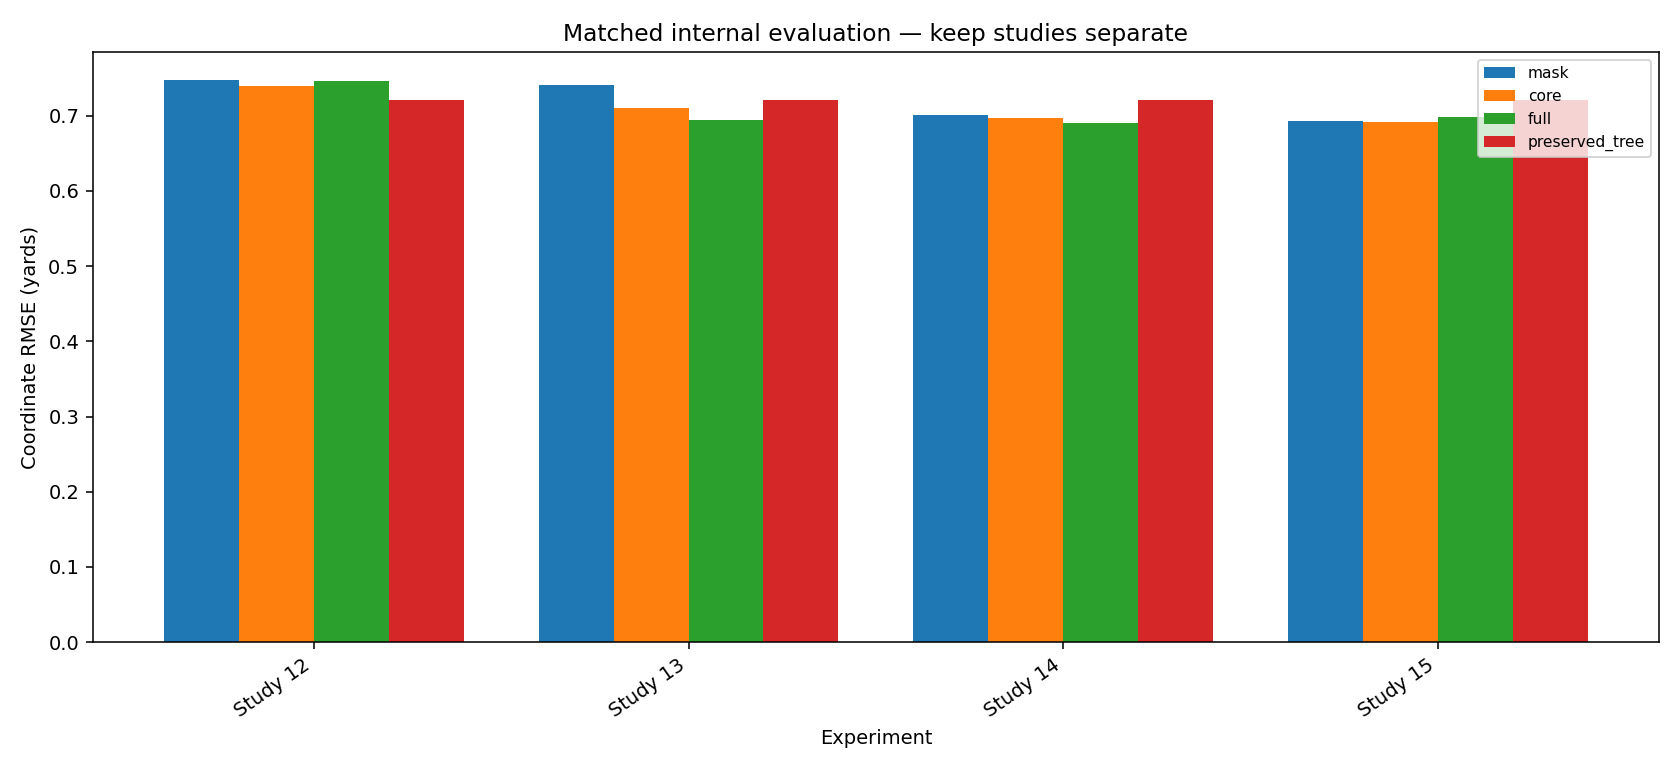

In [2]:
recent = [s for s in S if s.get('round') in (12,13,14,15) and s.get('metrics')]
fig = go.Figure()
for arm in ('mask','core','full','preserved_tree'):
    xs,ys = [],[]
    for s in recent:
        m = s['metrics'].get(arm)
        if isinstance(m,dict) and 'rmse' in m:
            xs.append('Study '+str(s['round']));ys.append(m['rmse'])
    if xs:fig.add_bar(name=arm,x=xs,y=ys)
show(style(fig,'Matched internal evaluation — keep studies separate','Experiment','Coordinate RMSE (yards)'))


## 2. Feature comparison uncertainty

Negative treatment-minus-control differences favor the treatment. Intervals crossing zero do not meet the evidence criterion. Adjustments are those recorded by the original experiment; reused validation games remain reused.


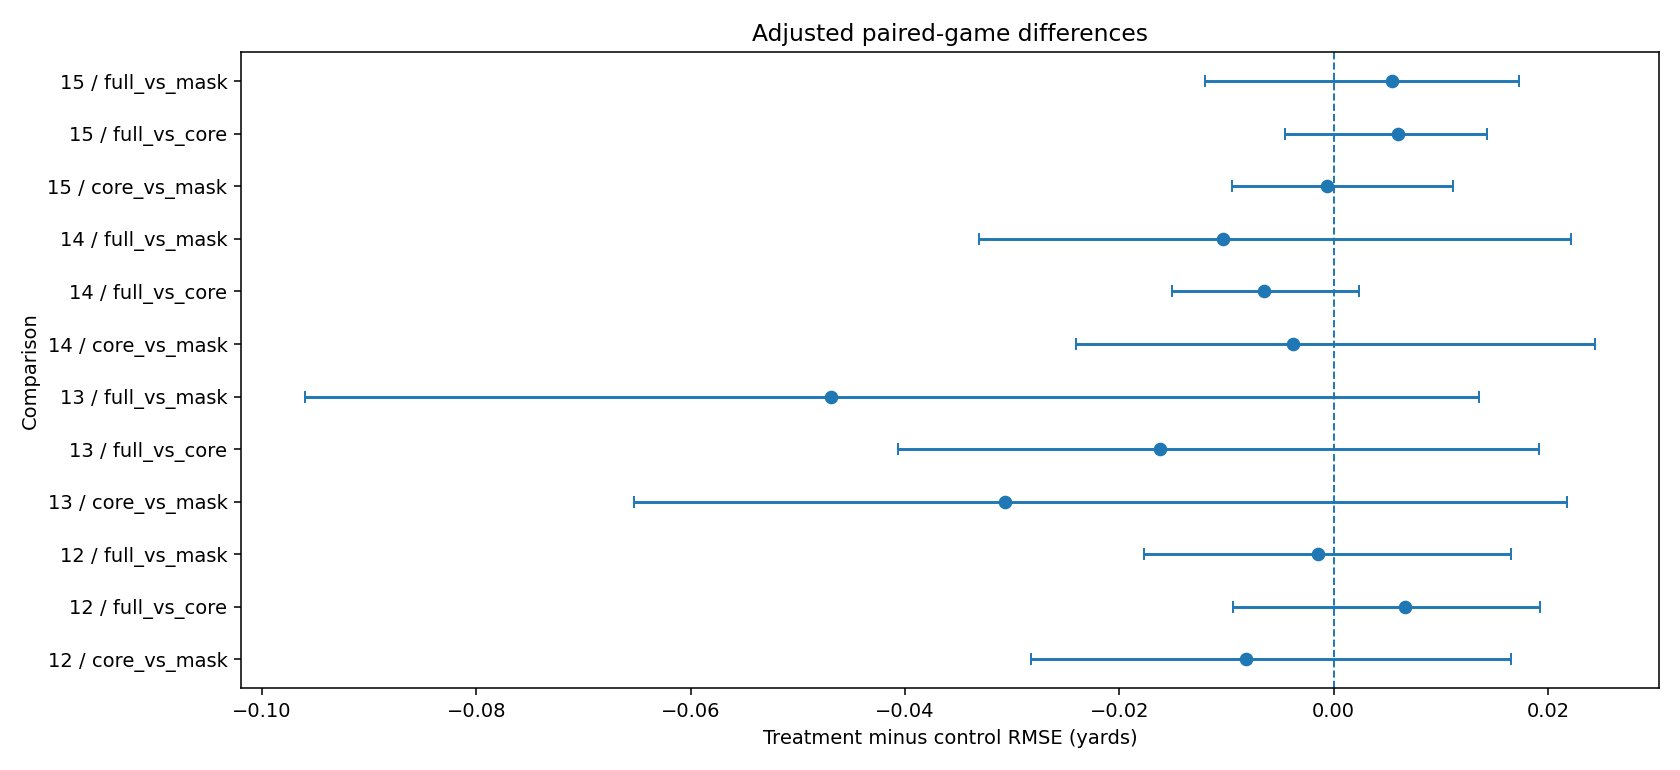

In [3]:
names,delta,upper,lower=[],[],[],[]
for s in recent:
    for label,c in s.get('contrasts',{}).items():
        if all(k in c for k in ('delta_rmse','low_adjusted','high_adjusted')):
            names.append(str(s['round'])+' / '+label);delta.append(c['delta_rmse'])
            upper.append(max(0,c['high_adjusted']-c['delta_rmse']))
            lower.append(max(0,c['delta_rmse']-c['low_adjusted']))
fig=go.Figure(go.Scatter(x=delta,y=names,mode='markers',error_x=dict(type='data',array=upper,arrayminus=lower)))
fig.add_vline(x=0)
show(style(fig,'Adjusted paired-game differences','Treatment minus control RMSE (yards)','Comparison'))


## 3. Final training fit versus evaluation

Final training error is not validation performance. The gap is descriptive and does not identify a single cause.


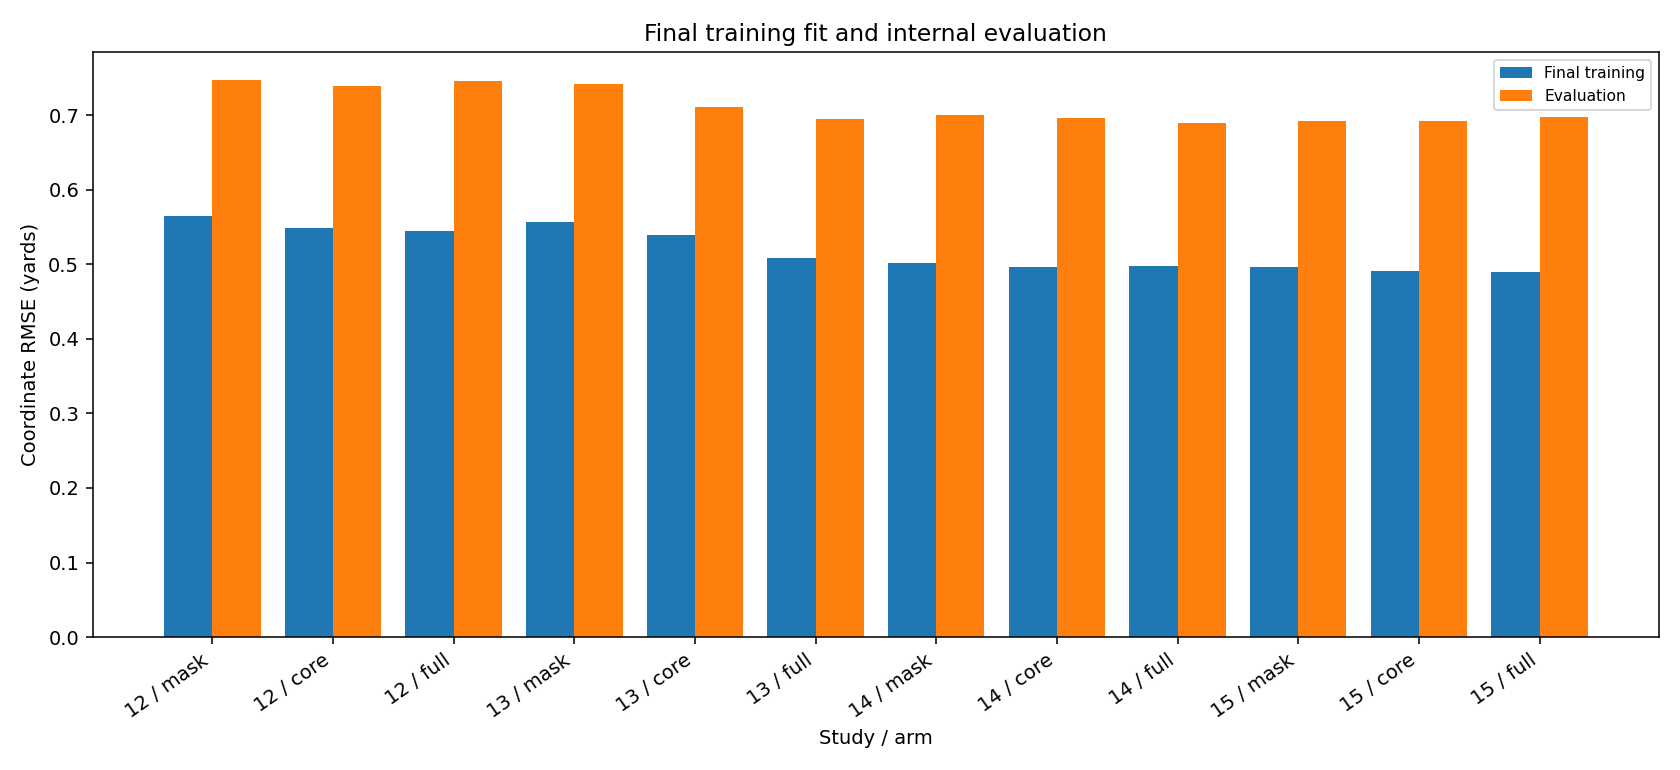

In [4]:
fig=go.Figure()
for scope in ('training_metrics','metrics'):
    x,y=[],[]
    for s in recent:
        for arm in ('mask','core','full'):
            m=s.get(scope,{}).get(arm)
            if isinstance(m,dict) and 'rmse' in m:x.append(str(s['round'])+' / '+arm);y.append(m['rmse'])
    fig.add_bar(x=x,y=y,name='Final training' if scope=='training_metrics' else 'Evaluation')
show(style(fig,'Final training fit and internal evaluation','Study / arm','Coordinate RMSE (yards)'))


## 4. Forecast horizon

All forecast rows remain in the official metric. Longer horizons are diagnostic segments, not separate model-selection targets.


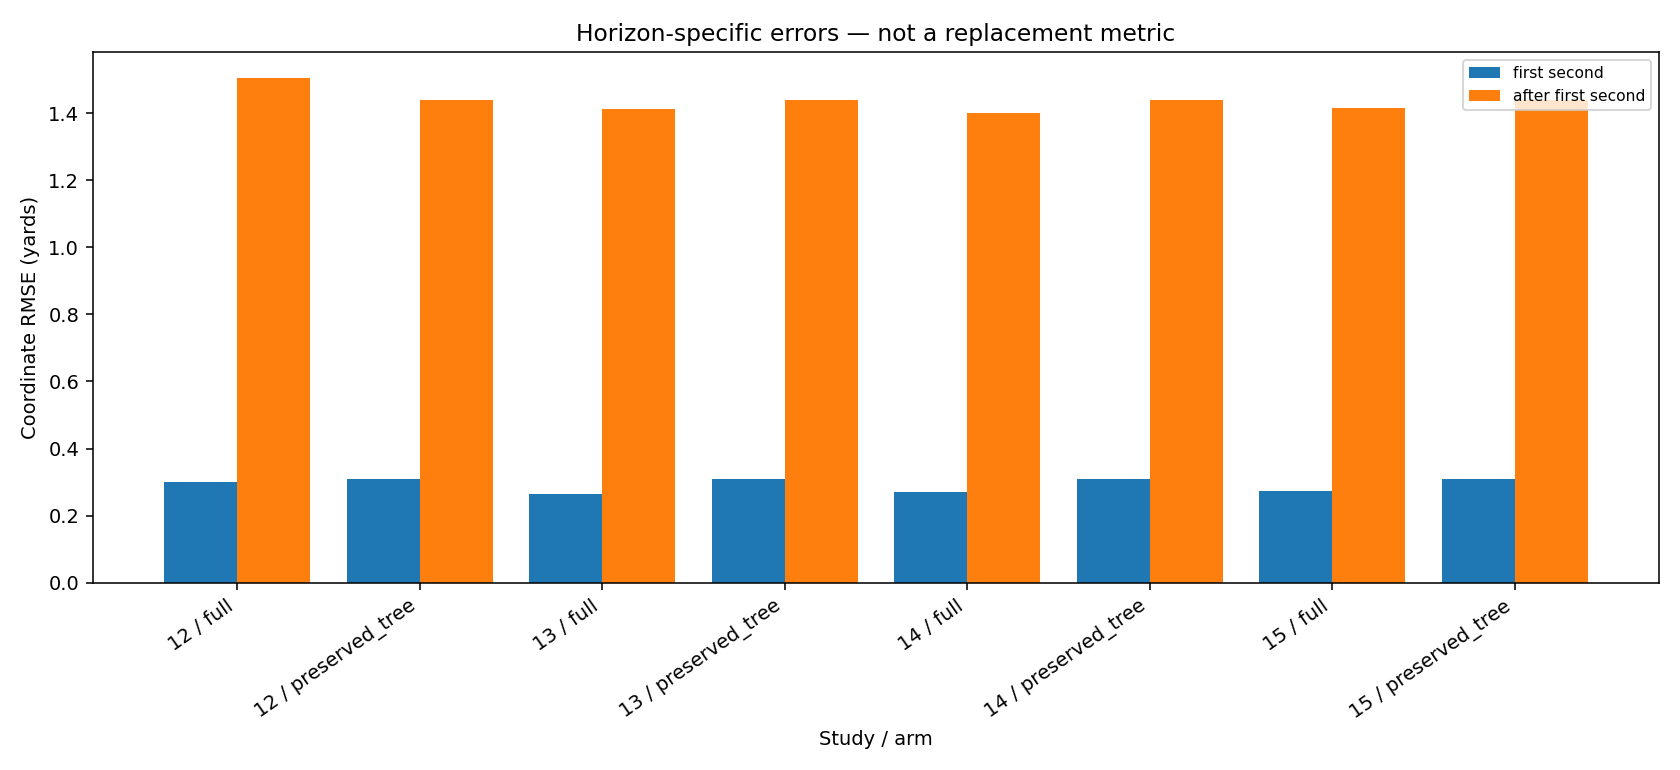

In [5]:
fig=go.Figure()
for region in ('first_second','after_first_second'):
    x,y=[],[]
    for s in recent:
        for item in s.get('slices',[]):
            if item.get('slice')==region and item.get('arm') in ('full','preserved_tree'):
                x.append(str(s['round'])+' / '+item['arm']);y.append(item['rmse'])
    fig.add_bar(x=x,y=y,name=region.replace('_',' '))
show(style(fig,'Horizon-specific errors — not a replacement metric','Study / arm','Coordinate RMSE (yards)'))


## 5. Training-label coverage and unfinished research

The label audit reports eligible data, not that larger-data models have been fitted. Readiness-only studies have no accuracy claim.


Study 1 : readiness only; no published accuracy result
Study 9 : readiness only; no published accuracy result
Study 11 : readiness only; no published accuracy result
Study 16 : readiness only; no published accuracy result
Study 17 : readiness only; no published accuracy result


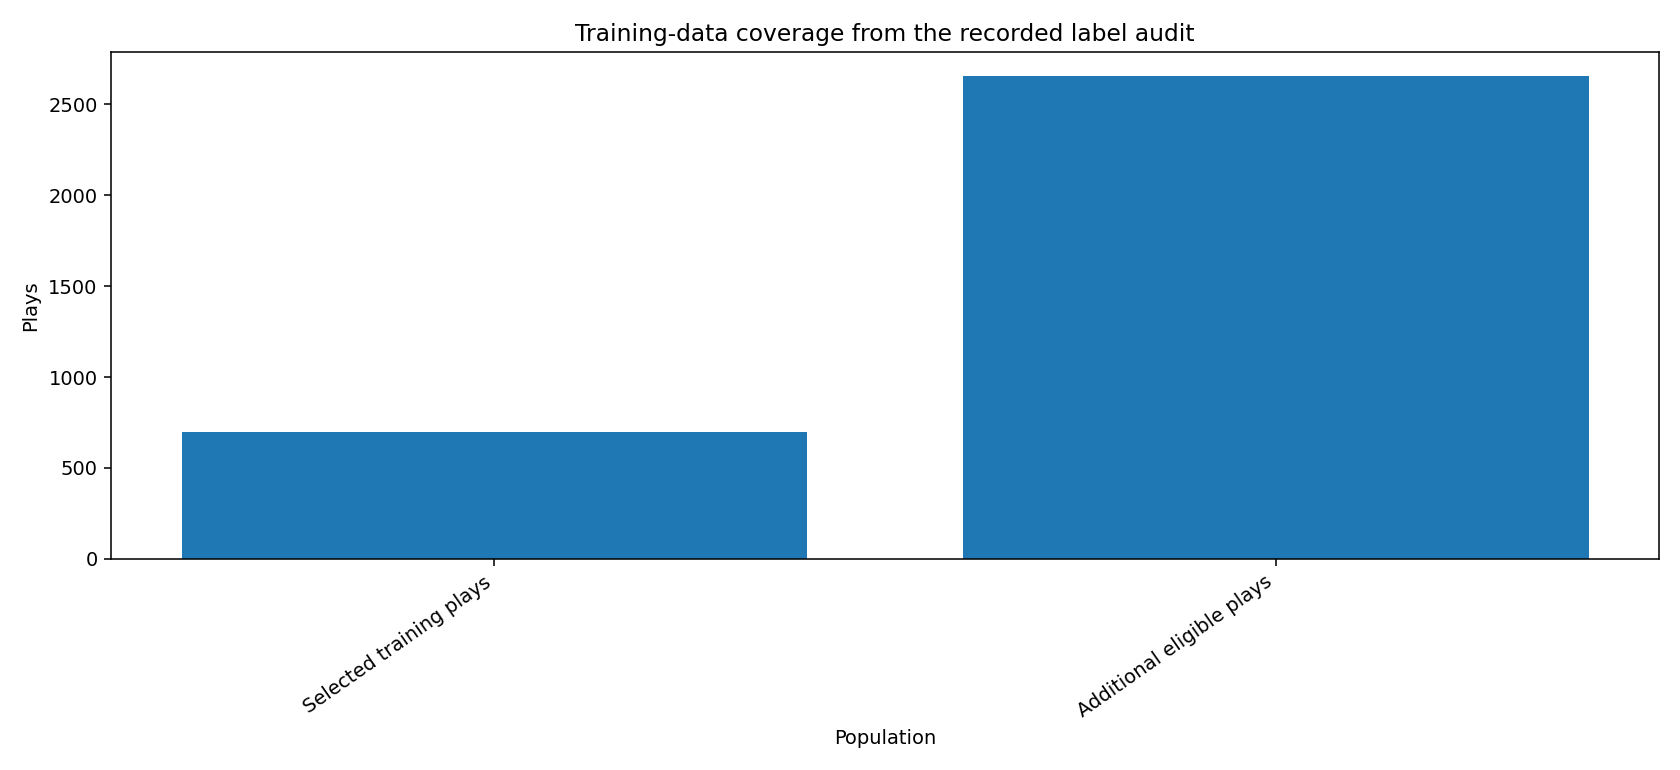

In [6]:
labels=E.get('label_readiness',{})
keys=['selected_training_plays','additional_label_eligible_plays']
fig=go.Figure(go.Bar(x=['Selected training plays','Additional eligible plays'],y=[labels.get(k,0) for k in keys]))
show(style(fig,'Training-data coverage from the recorded label audit','Population','Plays'))
for s in S:
    if s.get('status')=='no_published_accuracy_summary':
        print('Study',s['round'],': readiness only; no published accuracy result')


## Interpretation and next decision

No Kaggle record is claimed. Positive mean differences that fail uncertainty or temporal replication criteria remain inconclusive. Frozen scientific sources and earlier results are preserved for review, while data, weights, input contracts, and per-row diagnostics remain private. Broader training support and more defensible final assessment remain important alongside feature engineering.
